# Linear Regression

## Simple Linear Regression

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [144]:
df = pd.read_csv('height-weight.csv')

In [145]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


Text(0, 0.5, 'height')

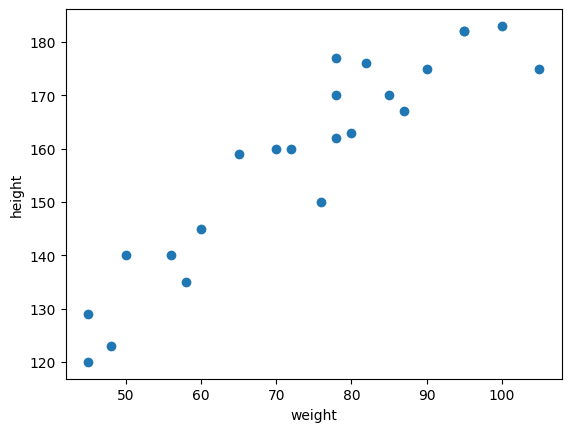

In [147]:
# we are creating simple lienar regression. (binary regression)
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('weight')
plt.ylabel('height')

In [148]:
# finding correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


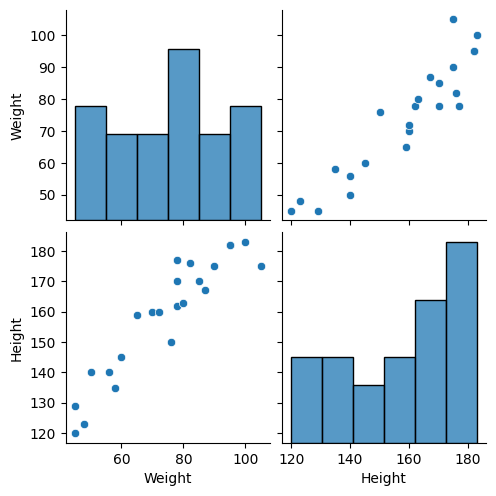

In [149]:
# seaborn for visualization
import seaborn as sns
sns.pairplot(df)

# they are linearly dependent

In [150]:
# applying simple linear regression now
# dividing features into dependent and independent features
X = df[['Weight']]  # independent features should be dataframe or 2-D array
print(type(X))

<class 'pandas.core.frame.DataFrame'>


In [151]:
X.shape

(23, 1)

In [152]:
y = df['Height']  # this is dependent feature and can be in Series or 1-D array
print(type(y))

<class 'pandas.core.series.Series'>


In [153]:
np.array(y).shape

(23,)

In [154]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state= 42)

In [155]:
X_train.shape

(17, 1)

In [156]:
X_test.shape

(6, 1)

In [157]:
# standardization: it is done to work on different units at once. so finding global minima is easier using Z-score. mean = 0 and std. = 1
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [158]:
X_train = scaler.fit_transform(X_train)

In [159]:
X_test = scaler.transform(X_test)     # transform is used to prevent data leakage. it means we want our model to use the mean and std. form the previous fit_transform


In [160]:
# Applying Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression()


In [161]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [162]:
regression

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [163]:
regression.coef_        # it gives the value of B1 (Coefficient)

array([17.2982057])

In [164]:
print("Coefficient or slope: ",regression.coef_)
print("Intercept : ", regression.intercept_)    # B0 (Intercept)

Coefficient or slope:  [17.2982057]
Intercept :  156.47058823529412


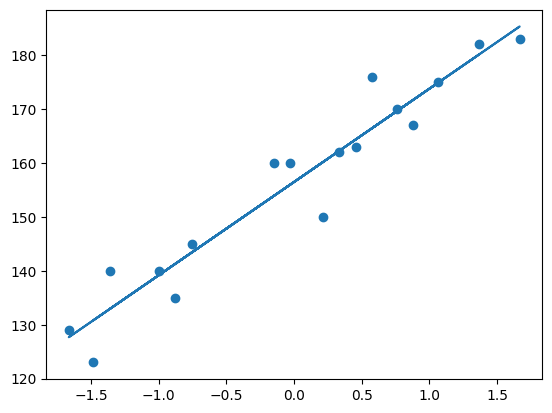

In [165]:
# lets visualize
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train))

## Prediction of test data
1. Predicted height output = intercept + coefficient(Weights)
2. y_pred_test = 156.470 + 17.29(X_test)

In [166]:
# prediction for the test data
y_pred = regression.predict(X_test)

In [167]:
print(y_pred)

[162.26499721 162.26499721 127.68347133 180.07972266 148.64197186
 190.55897293]


In [168]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [169]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


## R squared 
R^2 = 1 - SSR/SST
SSR = sum of squares of residuals 
SST = total sum of squares

In [120]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print (score)

0.7360826717981276


## Adjusted R squared
R2 = 1 - [(1-R2)(n-1)/(n-k-1)]
where:

R2 : The R2 of the model
n : number of observations
k : number of predicted variables

In [121]:
# displaying adjusted R2
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

# OLS Linear Regression

In [125]:
import statsmodels.api as su

In [126]:
model = su.OLS(y_train, X_train).fit()

In [128]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [129]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Fri, 20 Feb 2026   Prob (F-statistic):                       0.664
Time:                        00:01:42   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------